# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur agar visualisasi grafik terlihat rapi dan besar
plt.rcParams['figure.figsize'] = (14, 7)
sns.set_style('darkgrid')

print("Library untuk analisis saham ANTM")

Library untuk analisis saham ANTM


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [5]:
# Membaca data harian ANTM
df = pd.read_csv("/content/ANTM.csv")

# Mengubah kolom timestamp menjadi format tanggal khusus Python
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(f"Selesai! Data harian berhasil dimuat dengan total {len(df)} baris data.")
df.head()

Selesai! Data harian berhasil dimuat dengan total 5670 baris data.


,timestamp,open,low,high,close,volume
0,2001-04-16,432,407,436,432,0
1,2001-04-17,432,407,436,432,0
2,2001-04-18,432,407,436,432,0
3,2001-04-19,432,407,436,432,0
4,2001-04-20,432,407,436,432,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

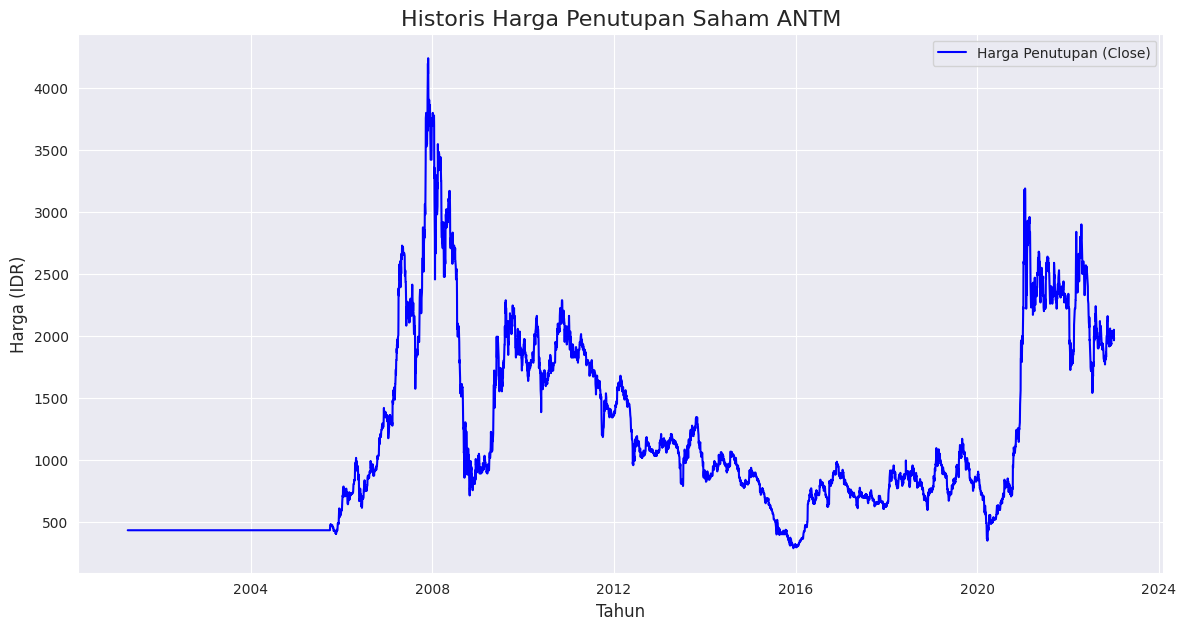

In [6]:
# Membuat grafik tren harga Close menggunakan kolom yang benar
plt.plot(df['timestamp'], df['close'], color='blue', label='Harga Penutupan (Close)')
plt.title('Historis Harga Penutupan Saham ANTM', fontsize=16)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Harga (IDR)', fontsize=12)
plt.legend()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [7]:
# Mengurutkan data berdasarkan tanggal dari terlama ke terbaru
df = df.sort_values('timestamp').reset_index(drop=True)

# Mengecek data kosong (NaN)
print("Jumlah data kosong per kolom:")
print(df.isnull().sum())

# Mengatasi data kosong dengan Forward Fill (jika ada hari libur/kosong yang terselip)
df = df.ffill()

# Memilih kolom utama yang sudah bersih untuk modelling nanti
df_clean = df[['timestamp', 'open', 'low', 'high', 'close', 'volume']]

# Menyimpan data bersih ke nama file yang diwajibkan oleh Dicoding
df_clean.to_csv("namadataset_preprocessing.csv", index=False)
print("\nProses Preprocessing Selesai! File 'namadataset_preprocessing.csv' berhasil dibuat.")

Jumlah data kosong per kolom:
timestamp    0
open         0
low          0
high         0
close        0
volume       0
dtype: int64

Proses Preprocessing Selesai! File 'namadataset_preprocessing.csv' berhasil dibuat.


In [8]:
script_code = """
import pandas as pd
import numpy as np
import os

def do_preprocessing(input_path, output_path):
    print("=== Memulai Otomatisasi Preprocessing Saham ANTM ===")

    # 1. Memuat Dataset
    if not os.path.exists(input_path):
        print(f"Error: File {input_path} tidak ditemukan!")
        return

    df = pd.read_csv(input_path)
    print(f"-> Berhasil memuat data. Total baris awal: {len(df)}")

    # 2. Mengubah tipe data timestamp
    df['timestamp'] = pd.to_datetime(df['timestamp'])

    # 3. Mengurutkan data berdasarkan tanggal
    df = df.sort_values('timestamp').reset_index(drop=True)

    # 4. Menangani data kosong (Forward Fill)
    df = df.ffill()

    # 5. Memilih kolom utama yang dibutuhkan
    df_clean = df[['timestamp', 'open', 'low', 'high', 'close', 'volume']]

    # 6. Menyimpan hasil bersih
    df_clean.to_csv(output_path, index=False)
    print(f"-> Preprocessing selesai! Data bersih disimpan di: {output_path}")
    print("=== Proses Selesai Sempurna ===")

if __name__ == '__main__':
    # Menentukan file input dan output secara otomatis
    input_file = "/content/ANTM.csv" # sesuaikan path-nya jika di lokal pc
    output_file = "namadataset_preprocessing.csv"

    do_preprocessing(input_file, output_file)
"""

with open("automate_Ashif.py", "w") as f:
    f.write(script_code.strip())

print("File automate_Ashif.py berhasil dibuat!")

File automate_Ashif.py berhasil dibuat!


In [9]:
!python automate_Ashif.py

=== Memulai Otomatisasi Preprocessing Saham ANTM ===
-> Berhasil memuat data. Total baris awal: 5670
-> Preprocessing selesai! Data bersih disimpan di: namadataset_preprocessing.csv
=== Proses Selesai Sempurna ===
